In [1]:
!pip install -q transformers timm pycocotools torchvision albumentations torchmetrics
!pip install -q roboflow

In [2]:
import os
import json
import glob
import random
import shutil
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torchvision
from torch.utils.data import DataLoader, Dataset
from transformers import DetrImageProcessor, DetrForObjectDetection, get_linear_schedule_with_warmup
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ====================== SEED ======================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

🚀 Device: cuda
GPU: NVIDIA A40


In [3]:
import os
import json
import glob
from roboflow import Roboflow

# ====================== TẢI DATASET TỪ ROBOFLOW ======================
# Thay YOUR_API_KEY bằng API key của bạn
rf = Roboflow(api_key="7cluP5yURKpTZxVV8Wh0")

project = rf.workspace("material-identification").project("garbage-classification-3")
dataset = project.version(2).download("coco")   # format COCO

print(f"✅ Dataset đã tải về tại: {dataset.location}")

# Đường dẫn sau khi tải
BASE_DIR = dataset.location

TRAIN_IMG_DIR = os.path.join(BASE_DIR, "train")
VAL_IMG_DIR   = os.path.join(BASE_DIR, "valid")
TEST_IMG_DIR  = os.path.join(BASE_DIR, "test")

# Roboflow COCO thường đặt file annotation tên là _annotations.coco.json
TRAIN_ANN_FILE = os.path.join(TRAIN_IMG_DIR, "_annotations.coco.json")
VAL_ANN_FILE   = os.path.join(VAL_IMG_DIR, "_annotations.coco.json")
TEST_ANN_FILE  = os.path.join(TEST_IMG_DIR, "_annotations.coco.json")

# Kiểm tra file tồn tại
for f in [TRAIN_ANN_FILE, VAL_ANN_FILE, TEST_ANN_FILE]:
    if not os.path.exists(f):
        # Phòng trường hợp tên file khác
        jsons = glob.glob(os.path.join(os.path.dirname(f), "*.json"))
        if jsons:
            print(f"⚠️ Không tìm thấy _annotations.coco.json, dùng: {jsons[0]}")
            if "train" in f:
                TRAIN_ANN_FILE = jsons[0]
            elif "valid" in f:
                VAL_ANN_FILE = jsons[0]
            else:
                TEST_ANN_FILE = jsons[0]
        else:
            raise FileNotFoundError(f"Không tìm thấy annotation trong {os.path.dirname(f)}")

print(f"Train ann: {TRAIN_ANN_FILE}")
print(f"Val ann  : {VAL_ANN_FILE}")
print(f"Test ann : {TEST_ANN_FILE}")

# ====================== ĐỌC ANNOTATION ======================
with open(TRAIN_ANN_FILE, 'r') as f:
    train_coco = json.load(f)
with open(VAL_ANN_FILE, 'r') as f:
    val_coco = json.load(f)
with open(TEST_ANN_FILE, 'r') as f:
    test_coco = json.load(f)

# ====================== REMAP CLASS (BỎ CLASS 0 RÁC) ======================
ORIGINAL_ID2LABEL = {c['id']: c['name'] for c in train_coco['categories']}
print("\nOriginal categories:", ORIGINAL_ID2LABEL)

# Chỉ giữ 6 class thật (bỏ class 0 nếu tồn tại)
KEEP_IDS = [cid for cid in sorted(ORIGINAL_ID2LABEL.keys()) if ORIGINAL_ID2LABEL[cid] != "GARBAGE-GARBAGE-CLASSIFICATION"]
# Nếu Roboflow đã bỏ class rác thì KEEP_IDS sẽ tự động đúng

id2label = {new_id: ORIGINAL_ID2LABEL[old_id] for new_id, old_id in enumerate(KEEP_IDS)}
label2id = {v: k for k, v in id2label.items()}

print("\n✅ Mapped id2label (6 classes):")
for k, v in id2label.items():
    print(f"  {k}: {v}")

# Thống kê
n_train = len(train_coco['images'])
n_val   = len(val_coco['images'])
n_test  = len(test_coco['images'])
print(f"\n📊 Dataset: Train={n_train} | Val={n_val} | Test={n_test}")

loading Roboflow workspace...
loading Roboflow project...


Extracting Dataset Version Zip to GARBAGE-CLASSIFICATION-3-2 in coco:: 100%|██████████| 10472/10472 [02:07<00:00, 82.39it/s]


✅ Dataset đã tải về tại: /workspace/GARBAGE-CLASSIFICATION-3-2
Train ann: /workspace/GARBAGE-CLASSIFICATION-3-2/train/_annotations.coco.json
Val ann  : /workspace/GARBAGE-CLASSIFICATION-3-2/valid/_annotations.coco.json
Test ann : /workspace/GARBAGE-CLASSIFICATION-3-2/test/_annotations.coco.json

Original categories: {0: 'GARBAGE-GARBAGE-CLASSIFICATION', 1: 'BIODEGRADABLE', 2: 'CARDBOARD', 3: 'GLASS', 4: 'METAL', 5: 'PAPER', 6: 'PLASTIC'}

✅ Mapped id2label (6 classes):
  0: BIODEGRADABLE
  1: CARDBOARD
  2: GLASS
  3: METAL
  4: PAPER
  5: PLASTIC

📊 Dataset: Train=7324 | Val=2098 | Test=1042


In [24]:
# ====================== AUGMENTATION ======================
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.3),
    A.GaussNoise(p=0.1),
], bbox_params=A.BboxParams(format='coco', label_fields=['category_ids'], min_visibility=0.3))

class CocoDetectionDataset(Dataset):
    def __init__(self, img_folder, ann_file, processor, transform=None, is_train=False, keep_ids=None):
        self.coco = torchvision.datasets.CocoDetection(img_folder, ann_file)
        self.processor = processor
        self.transform = transform
        self.is_train = is_train
        
        # Dùng KEEP_IDS động thay vì hardcode
        if keep_ids is None:
            keep_ids = [1, 2, 3, 4, 5, 6]
        self.old2new = {old: new for new, old in enumerate(keep_ids)}

    def __len__(self):
        return len(self.coco)

    def __getitem__(self, idx):
        image, target = self.coco[idx]
        image = np.array(image.convert("RGB"))
        h, w = image.shape[:2]

        # Remap labels + lọc annotation không thuộc KEEP_IDS + lọc bbox lỗi
        new_annotations = []
        for ann in target:
            old_cat = ann['category_id']
            if old_cat not in self.old2new:
                continue

            x, y, bw, bh = ann['bbox']
            
            # Lọc bbox không hợp lệ
            if bw <= 1 or bh <= 1:
                continue
                
            # Clip bbox nằm trong ảnh
            x = max(0, min(x, w - 1))
            y = max(0, min(y, h - 1))
            bw = max(1, min(bw, w - x))
            bh = max(1, min(bh, h - y))

            ann = ann.copy()
            ann['bbox'] = [x, y, bw, bh]
            ann['category_id'] = self.old2new[old_cat]
            new_annotations.append(ann)

        if self.transform and self.is_train and len(new_annotations) > 0:
            bboxes = [ann['bbox'] for ann in new_annotations]
            category_ids = [ann['category_id'] for ann in new_annotations]

            try:
                transformed = self.transform(
                    image=image,
                    bboxes=bboxes,
                    category_ids=category_ids
                )
                image = transformed['image']

                new_annotations = []
                for bbox, cat_id in zip(transformed['bboxes'], transformed['category_ids']):
                    new_annotations.append({
                        'bbox': list(bbox),
                        'category_id': cat_id,
                        'area': bbox[2] * bbox[3],
                        'iscrowd': 0
                    })
            except Exception:
                # Nếu transform vẫn lỗi thì bỏ augmentation cho ảnh này
                pass

        formatted = {
            "image_id": idx,
            "annotations": new_annotations
        }

        encoding = self.processor(images=image, annotations=formatted, return_tensors="pt")
        return encoding["pixel_values"].squeeze(0), encoding["labels"][0]

def collate_fn(batch):
    pixel_values = torch.stack([item[0] for item in batch])
    labels = [item[1] for item in batch]
    
    # Tạo pixel_mask toàn bộ bằng 1 (vì ảnh đã cùng kích thước)
    pixel_mask = torch.ones(
        (pixel_values.shape[0], pixel_values.shape[2], pixel_values.shape[3]),
        dtype=torch.long
    )
    
    return {
        "pixel_values": pixel_values,
        "pixel_mask": pixel_mask,
        "labels": labels
    }

In [25]:
MODEL_NAME = "facebook/detr-resnet-50"

# Size khớp ảnh gốc 416x416
processor = DetrImageProcessor.from_pretrained(
    MODEL_NAME,
    size={"shortest_edge": 416, "longest_edge": 416}
)

train_dataset = CocoDetectionDataset(
    TRAIN_IMG_DIR, TRAIN_ANN_FILE, processor,
    transform=train_transform, is_train=True,
    keep_ids=KEEP_IDS
)

val_dataset = CocoDetectionDataset(
    VAL_IMG_DIR, VAL_ANN_FILE, processor,
    transform=None, is_train=False,
    keep_ids=KEEP_IDS
)

# ====================== TỐI ƯU CHO A40 ======================
TRAIN_BATCH_SIZE = 24
EVAL_BATCH_SIZE  = 24
NUM_WORKERS      = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=False,   # ← quan trọng: để False cho Jupyter
    prefetch_factor=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=False,   # ← quan trọng
    prefetch_factor=2
)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")
print(f"Batch size: {TRAIN_BATCH_SIZE} | Workers: {NUM_WORKERS}")
print(f"id2label: {id2label}")

loading annotations into memory...
Done (t=0.23s)
creating index...
index created!
loading annotations into memory...
Done (t=0.06s)
creating index...
index created!
Train batches: 306 | Val batches: 88
Batch size: 24 | Workers: 8
id2label: {0: 'BIODEGRADABLE', 1: 'CARDBOARD', 2: 'GLASS', 3: 'METAL', 4: 'PAPER', 5: 'PLASTIC'}


In [29]:
model = DetrForObjectDetection.from_pretrained(
    MODEL_NAME,
    num_labels=len(id2label),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
).to(device)

# ====================== DIFFERENTIAL LR (chuẩn DETR) ======================
param_dicts = [
    {
        "params": [p for n, p in model.named_parameters() 
                   if "backbone" not in n and p.requires_grad]
    },
    {
        "params": [p for n, p in model.named_parameters() 
                   if "backbone" in n and p.requires_grad],
        "lr": 1e-5,
    },
]

optimizer = torch.optim.AdamW(param_dicts, lr=1e-4, weight_decay=1e-4)

NUM_EPOCHS = 30
total_steps = len(train_loader) * NUM_EPOCHS

lr_scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.05 * total_steps),
    num_training_steps=total_steps
)

scaler = torch.amp.GradScaler('cuda')

# Compile model (tăng tốc)
model = torch.compile(model)

print(f"Model ready | num_labels = {len(id2label)}")
print(f"Total steps: {total_steps} | Batch size: {TRAIN_BATCH_SIZE}")

[transformers] You passed `num_labels=6` which is incompatible to the `id2label` map of length `91`.


Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

[transformers] DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |                                                                                        
---------------------------------------------------------------+------------+----------------------------------------------------------------------------------------
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                        
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |             

Model ready | num_labels = 6
Total steps: 9180 | Batch size: 24


In [30]:
import os
import shutil
from tqdm import tqdm

# ====================== ĐƯỜNG DẪN LƯU ======================
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

SAVE_DIR_BEST = os.path.join(OUTPUT_DIR, "saved_detr_best")
SAVE_DIR_LAST = os.path.join(OUTPUT_DIR, "saved_detr_last")
RESUME_FILE   = os.path.join(OUTPUT_DIR, "resume_training_state.pt")

os.makedirs(SAVE_DIR_BEST, exist_ok=True)
os.makedirs(SAVE_DIR_LAST, exist_ok=True)

best_val_loss = float("inf")
start_epoch = 0

# Hàm lưu an toàn khi dùng torch.compile
def save_model_safe(model, processor, save_dir):
    os.makedirs(save_dir, exist_ok=True)
    model_to_save = model._orig_mod if hasattr(model, "_orig_mod") else model
    model_to_save.save_pretrained(save_dir)
    processor.save_pretrained(save_dir)

# ====================== RESUME ======================
if os.path.exists(RESUME_FILE):
    print(f"🔄 Tìm thấy checkpoint → đang resume...")
    ckpt = torch.load(RESUME_FILE, map_location=device)
    
    # Load vào model gốc nếu đã compile
    model_to_load = model._orig_mod if hasattr(model, "_orig_mod") else model
    model_to_load.load_state_dict(ckpt['model_state_dict'])
    
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    lr_scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    scaler.load_state_dict(ckpt['scaler_state_dict'])
    start_epoch = ckpt['epoch'] + 1
    best_val_loss = ckpt['best_val_loss']
    print(f"✅ Resume từ Epoch {start_epoch + 1}/{NUM_EPOCHS}")
else:
    print(f"⚙️ Bắt đầu train mới từ Epoch 1/{NUM_EPOCHS}")

# ====================== TRAINING ======================
history = {"train_loss": [], "val_loss": []}

for epoch in range(start_epoch, NUM_EPOCHS):
    # ----- Train -----
    model.train()
    train_loss = 0.0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{NUM_EPOCHS} [Train]")
    for batch in pbar:
        pixel_values = batch["pixel_values"].to(device)
        pixel_mask   = batch["pixel_mask"].to(device)
        labels = [{k: v.to(device) for k, v in t.items()} for t in batch["labels"]]

        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask, labels=labels)
            loss = outputs.loss

        scaler.scale(loss).backward()
        
        # Gradient clipping (quan trọng)
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.1)
        
        scaler.step(optimizer)
        scaler.update()
        lr_scheduler.step()

        train_loss += loss.item()
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    train_loss /= len(train_loader)
    history["train_loss"].append(train_loss)

    # ----- Validation -----
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1:02d}/{NUM_EPOCHS} [Val]"):
            pixel_values = batch["pixel_values"].to(device)
            pixel_mask   = batch["pixel_mask"].to(device)
            labels = [{k: v.to(device) for k, v in t.items()} for t in batch["labels"]]

            with torch.amp.autocast('cuda'):
                outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask, labels=labels)
                val_loss += outputs.loss.item()

    val_loss /= len(val_loader)
    history["val_loss"].append(val_loss)

    print(f"\n[Epoch {epoch+1:02d}] Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    # ----- Save Last -----
    save_model_safe(model, processor, SAVE_DIR_LAST)

    # ----- Save Best -----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        print(f"→ New best Val Loss: {val_loss:.4f} → lưu vào {SAVE_DIR_BEST}")
        save_model_safe(model, processor, SAVE_DIR_BEST)

    # ----- Milestone + Resume mỗi 5 epoch -----
    if (epoch + 1) % 5 == 0 or (epoch + 1) == NUM_EPOCHS:
        for tag, src in [("best", SAVE_DIR_BEST), ("last", SAVE_DIR_LAST)]:
            dst = os.path.join(OUTPUT_DIR, f"saved_detr_{tag}_epoch_{epoch+1:02d}")
            if os.path.exists(dst):
                shutil.rmtree(dst)
            shutil.copytree(src, dst)
            print(f"→ Đã lưu mốc {tag} epoch {epoch+1}")

        # Lưu state dict từ model gốc
        model_to_save = model._orig_mod if hasattr(model, "_orig_mod") else model
        torch.save({
            'epoch': epoch,
            'model_state_dict': model_to_save.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': lr_scheduler.state_dict(),
            'scaler_state_dict': scaler.state_dict(),
            'best_val_loss': best_val_loss
        }, RESUME_FILE)
        print(f"[RESUME] Đã cập nhật checkpoint tại epoch {epoch+1}")

print("\n🎉 HUẤN LUYỆN HOÀN TẤT!")

⚙️ Bắt đầu train mới từ Epoch 1/30


Epoch 01/30 [Val]: 100%|██████████| 88/88 [00:11<00:00,  7.34it/s]



[Epoch 01] Train Loss: 2.8865 | Val Loss: 2.1001


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

→ New best Val Loss: 2.1001 → lưu vào outputs/saved_detr_best


...


[Epoch 30] Train Loss: 1.2627 | Val Loss: 1.4218


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

→ New best Val Loss: 1.4218 → lưu vào outputs/saved_detr_best


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

→ Đã lưu mốc best epoch 30
→ Đã lưu mốc last epoch 30
[RESUME] Đã cập nhật checkpoint tại epoch 30

🎉 HUẤN LUYỆN HOÀN TẤT!


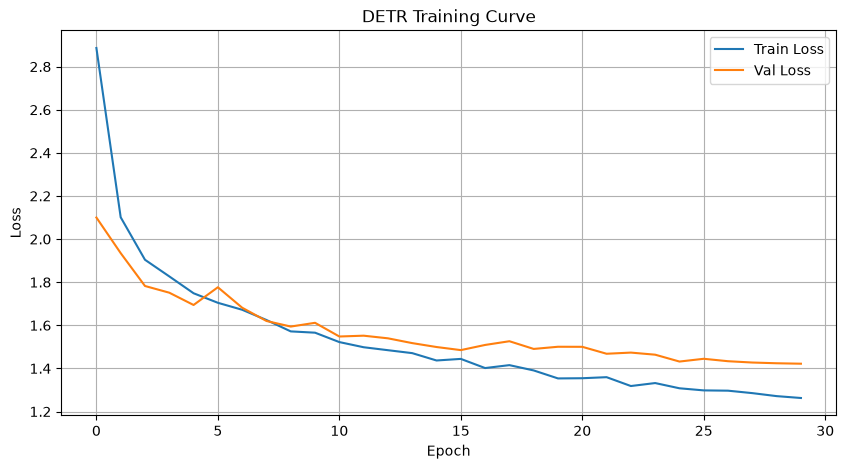

In [31]:
plt.figure(figsize=(10, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DETR Training Curve")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(OUTPUT_DIR, "detr_loss_curve.png"), dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
import os
import shutil
from datetime import datetime
from transformers import DetrForObjectDetection, DetrImageProcessor

# =========================================================
# CẤU HÌNH ĐƯỜNG DẪN
# =========================================================
OUTPUT_DIR = "outputs"
SAVE_DIR_BEST = os.path.join(OUTPUT_DIR, "saved_detr_best")

# Thư mục cuối cùng sẽ lưu model tốt nhất (dễ nhận biết)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
FINAL_SAVE_DIR = os.path.join(OUTPUT_DIR, f"detr_best_final_{timestamp}")

os.makedirs(OUTPUT_DIR, exist_ok=True)

# =========================================================
# HÀM LƯU AN TOÀN (hỗ trợ cả model đã torch.compile)
# =========================================================
def save_best_model(model, processor, save_dir):
    os.makedirs(save_dir, exist_ok=True)
    
    # Lấy model gốc nếu đã bị compile
    model_to_save = model._orig_mod if hasattr(model, "_orig_mod") else model
    
    model_to_save.save_pretrained(save_dir)
    processor.save_pretrained(save_dir)
    
    print(f"✅ Đã lưu thành công model + processor vào:")
    print(f"   → {os.path.abspath(save_dir)}")
    return save_dir

# =========================================================
# THỰC HIỆN LƯU
# =========================================================
print("🔄 Đang lưu trọng số mô hình tốt nhất ra ổ đĩa...")

# Cách 1: Nếu bạn đang ở trong session training và biến model + processor vẫn còn
try:
    final_path = save_best_model(model, processor, FINAL_SAVE_DIR)
except NameError:
    # Cách 2: Nếu đã restart kernel hoặc không còn biến model → load từ thư mục best đã lưu trước đó
    print("⚠️ Không tìm thấy biến model trong memory → load từ saved_detr_best...")
    
    if not os.path.exists(SAVE_DIR_BEST):
        raise FileNotFoundError(f"Không tìm thấy model tại: {SAVE_DIR_BEST}")
    
    model = DetrForObjectDetection.from_pretrained(SAVE_DIR_BEST)
    processor = DetrImageProcessor.from_pretrained(SAVE_DIR_BEST)
    
    final_path = save_best_model(model, processor, FINAL_SAVE_DIR)

# =========================================================
# KIỂM TRA KẾT QUẢ
# =========================================================
print("\n📁 Các file đã được lưu:")
for f in sorted(os.listdir(final_path)):
    size_mb = os.path.getsize(os.path.join(final_path, f)) / (1024 * 1024)
    print(f"   - {f:30s} {size_mb:7.2f} MB")

print(f"\n🎉 Hoàn tất! Model tốt nhất đã được lưu tại:")
print(f"   {os.path.abspath(final_path)}")

In [33]:
!pip install -q pandas

In [34]:
import os
import json
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from PIL import Image
from tqdm import tqdm
from transformers import DetrImageProcessor, DetrForObjectDetection

# ==============================================================================
# 0. ĐƯỜNG DẪN (KHÔNG CÒN KAGGLE)
# ==============================================================================
OUTPUT_DIR = "outputs"
SAVE_DIR_BEST = os.path.join(OUTPUT_DIR, "saved_detr_best")
SAVE_DIR_LAST = os.path.join(OUTPUT_DIR, "saved_detr_last")

# Kiểm tra model đã train chưa
if not os.path.exists(SAVE_DIR_BEST):
    raise FileNotFoundError(f"Không tìm thấy model best tại: {SAVE_DIR_BEST}")

# Các biến này phải đã được định nghĩa ở cell load dataset trước đó
# TEST_IMG_DIR, TEST_ANN_FILE

IOU_MATCH = 0.50
CONF_FOR_PRF1 = 0.25
IOU_THRESHOLDS = np.round(np.arange(0.50, 0.96, 0.05), 2)

# Danh sách 6 lớp (phải khớp thứ tự id2label lúc train)
names = ['BIODEGRADABLE', 'CARDBOARD', 'GLASS', 'METAL', 'PAPER', 'PLASTIC']

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Load model + processor tốt nhất
eval_model = DetrForObjectDetection.from_pretrained(SAVE_DIR_BEST).to(device)
eval_model.eval()
eval_processor = DetrImageProcessor.from_pretrained(SAVE_DIR_BEST)

# ==============================================================================
# 1. NẠP GROUND TRUTH + ÁNH XẠ 6 LỚP
# ==============================================================================
print("⏳ Đang nạp Ground Truth và ánh xạ 6 lớp chuẩn...")

with open(TEST_ANN_FILE, 'r') as f:
    test_coco_data = json.load(f)

# Map từ category_id gốc trong file COCO → id chuẩn 0..5
coco_id_to_target = {}
for cat in test_coco_data['categories']:
    if cat['name'] in names:
        coco_id_to_target[cat['id']] = names.index(cat['name'])

print("Mapping COCO ID → target ID:", coco_id_to_target)

img_info = {
    img['id']: {
        'file_name': img['file_name'],
        'width': img['width'],
        'height': img['height'],
        'stem': Path(img['file_name']).stem
    }
    for img in test_coco_data['images']
}

image_stems = sorted([info['stem'] for info in img_info.values()])

# Đọc Ground Truth
GT = {stem: ([], []) for stem in image_stems}
for ann in test_coco_data['annotations']:
    if ann['category_id'] in coco_id_to_target:
        info = img_info[ann['image_id']]
        stem = info['stem']
        w_img, h_img = info['width'], info['height']
        x, y, w, h = ann['bbox']
        
        norm_xyxy = [x / w_img, y / h_img, (x + w) / w_img, (y + h) / h_img]
        cid = coco_id_to_target[ann['category_id']]
        
        GT[stem][0].append(cid)
        GT[stem][1].append(norm_xyxy)

for stem in image_stems:
    cids, boxes = GT[stem]
    GT[stem] = (
        np.array(cids, dtype=int),
        np.clip(np.array(boxes, dtype=float), 0, 1) if len(boxes) else np.zeros((0, 4))
    )

# ==============================================================================
# 2. INFERENCE DETR
# ==============================================================================
print("🚀 Đang chạy Inference DETR trên toàn bộ tập Test...")
PRED = {}

for img_id, info in tqdm(img_info.items(), desc="DETR Predicting"):
    stem = info['stem']
    img_path = os.path.join(TEST_IMG_DIR, info['file_name'])
    image = Image.open(img_path).convert("RGB")
    w_img, h_img = info['width'], info['height']

    inputs = eval_processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            outputs = eval_model(**inputs)

    # Post-process
    target_sizes = torch.tensor([[h_img, w_img]]).to(device)
    results = eval_processor.post_process_object_detection(
        outputs, target_sizes=target_sizes, threshold=0.01
    )[0]

    raw_boxes = results['boxes'].cpu().numpy()
    raw_scores = results['scores'].cpu().numpy()
    raw_labels = results['labels'].cpu().numpy()   # Đã là 0→5 sau khi finetune

    p_boxes, p_scores, p_labels = [], [], []
    for box, score, label in zip(raw_boxes, raw_scores, raw_labels):
        # label đã nằm trong 0..5, chỉ cần kiểm tra hợp lệ
        if 0 <= label < len(names):
            norm_box = [box[0] / w_img, box[1] / h_img, box[2] / w_img, box[3] / h_img]
            p_boxes.append(norm_box)
            p_scores.append(score)
            p_labels.append(int(label))

    if len(p_boxes) > 0:
        PRED[stem] = (
            np.array(p_labels, dtype=int),
            np.clip(np.array(p_boxes, dtype=float), 0, 1),
            np.array(p_scores, dtype=float)
        )
    else:
        PRED[stem] = (np.array([], dtype=int), np.zeros((0, 4)), np.array([]))

# ==============================================================================
# 3. HÀM TÍNH METRICS
# ==============================================================================
def box_iou_matrix(a, b):
    if len(a) == 0 or len(b) == 0:
        return np.zeros((len(a), len(b)))
    lt = np.maximum(a[:, None, :2], b[None, :, :2])
    rb = np.minimum(a[:, None, 2:], b[None, :, 2:])
    wh = np.clip(rb - lt, 0, None)
    inter = wh[:, :, 0] * wh[:, :, 1]
    area_a = np.clip(a[:, 2] - a[:, 0], 0, None) * np.clip(a[:, 3] - a[:, 1], 0, None)
    area_b = np.clip(b[:, 2] - b[:, 0], 0, None) * np.clip(b[:, 3] - b[:, 1], 0, None)
    return inter / (area_a[:, None] + area_b[None, :] - inter + 1e-9)

def compute_ap(recall, precision):
    if len(recall) == 0:
        return 0.0
    mrec = np.r_[0.0, recall, 1.0]
    mpre = np.r_[1.0, precision, 0.0]
    mpre = np.maximum.accumulate(mpre[::-1])[::-1]
    x = np.linspace(0, 1, 101)
    trapz = getattr(np, "trapezoid", np.trapz)
    return float(trapz(np.interp(x, mrec, mpre), x))

def collect_class(cid):
    gts, preds, n_gt = {}, [], 0
    for stem in image_stems:
        gc, gb = GT[stem]
        pc, pb, ps = PRED[stem]
        gboxes = gb[gc == cid]
        gts[stem] = gboxes
        n_gt += len(gboxes)
        for box, score in zip(pb[pc == cid], ps[pc == cid]):
            preds.append((stem, float(score), box))
    preds.sort(key=lambda x: x[1], reverse=True)
    return gts, preds, n_gt

def match_predictions(gts, preds, iou_thr, conf_min=None):
    if conf_min is not None:
        preds = [p for p in preds if p[1] >= conf_min]

    used = {stem: np.zeros(len(boxes), dtype=bool) for stem, boxes in gts.items()}
    tp = np.zeros(len(preds))
    fp = np.zeros(len(preds))
    matched_ious = []

    for i, (stem, score, box) in enumerate(preds):
        boxes = gts.get(stem, np.zeros((0, 4)))
        if len(boxes):
            ious = box_iou_matrix(box[None, :], boxes)[0]
            best_idx = int(np.argmax(ious))
            best_iou = float(ious[best_idx])
        else:
            best_idx, best_iou = -1, 0.0

        if best_iou >= iou_thr and best_idx >= 0 and not used[stem][best_idx]:
            tp[i] = 1
            used[stem][best_idx] = True
            matched_ious.append(best_iou)
        else:
            fp[i] = 1

    return tp, fp, matched_ious

def evaluate_at_iou(iou_thr):
    rows = []
    total_tp = total_fp = total_fn = 0
    all_ious, ap_values = [], []

    for cid, cname in enumerate(names):
        gts, preds, n_gt = collect_class(cid)

        tp_all, fp_all, _ = match_predictions(gts, preds, iou_thr)
        recall_curve = np.cumsum(tp_all) / (n_gt + 1e-9)
        precision_curve = np.cumsum(tp_all) / (np.cumsum(tp_all) + np.cumsum(fp_all) + 1e-9)
        ap = compute_ap(recall_curve, precision_curve) if n_gt > 0 else np.nan

        tp_fixed, fp_fixed, matched_ious = match_predictions(gts, preds, iou_thr, conf_min=CONF_FOR_PRF1)

        tp = int(tp_fixed.sum())
        fp = int(fp_fixed.sum())
        fn = int(n_gt - tp)

        precision = tp / (tp + fp + 1e-9)
        recall = tp / (tp + fn + 1e-9)
        f1 = 2 * precision * recall / (precision + recall + 1e-9)

        rows.append({
            "class_id": cid,
            "class_name": cname,
            "gt_boxes": n_gt,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "mean_matched_IoU": float(np.mean(matched_ious)) if matched_ious else 0.0,
            "Precision": precision,
            "Recall": recall,
            "F1-score": f1,
            "AP": ap,
        })

        if n_gt > 0:
            ap_values.append(ap)
        total_tp += tp
        total_fp += fp
        total_fn += fn
        all_ious.extend(matched_ious)

    precision = total_tp / (total_tp + total_fp + 1e-9)
    recall = total_tp / (total_tp + total_fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)

    summary = {
        "IoU_threshold": iou_thr,
        "confidence_for_P_R_F1": CONF_FOR_PRF1,
        "mean_matched_IoU": float(np.mean(all_ious)) if all_ious else 0.0,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "mAP": float(np.nanmean(ap_values)),
    }

    return pd.DataFrame(rows), summary

# ==============================================================================
# 4. CHẠY ĐÁNH GIÁ + XUẤT FILE
# ==============================================================================
print("📊 Đang tính toán metrics...")
per_class_50, summary_50 = evaluate_at_iou(IOU_MATCH)

map_curve = []
for t in IOU_THRESHOLDS:
    _, s = evaluate_at_iou(float(t))
    map_curve.append({"IoU_threshold": float(t), "mAP": s["mAP"]})

map_curve = pd.DataFrame(map_curve)
summary_50["mAP@0.5:0.95_custom"] = map_curve["mAP"].mean()

print("\n--- 1. CHI TIẾT TỪNG CLASS (DETR @ IoU=0.50) ---")
display(per_class_50)

print("\n--- 2. TỔNG KẾT METRICS TOÀN DIỆN (DETR) ---")
display(pd.DataFrame([summary_50]))

print("\n--- 3. ĐƯỜNG CONG mAP THEO IoU (0.50 → 0.95) ---")
display(map_curve)

# Xuất CSV
os.makedirs(OUTPUT_DIR, exist_ok=True)
per_class_50.to_csv(os.path.join(OUTPUT_DIR, "detr_test_per_class_metrics_iou50.csv"), index=False)
pd.DataFrame([summary_50]).to_csv(os.path.join(OUTPUT_DIR, "detr_test_summary_metrics.csv"), index=False)
map_curve.to_csv(os.path.join(OUTPUT_DIR, "detr_test_map_by_iou.csv"), index=False)

print(f"\n✅ Đã xuất 3 file CSV vào thư mục: {OUTPUT_DIR}/")

Device: cuda


Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

⏳ Đang nạp Ground Truth và ánh xạ 6 lớp chuẩn...
Mapping COCO ID → target ID: {1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5}
🚀 Đang chạy Inference DETR trên toàn bộ tập Test...


DETR Predicting: 100%|██████████| 1042/1042 [01:00<00:00, 17.22it/s]


📊 Đang tính toán metrics...

--- 1. CHI TIẾT TỪNG CLASS (DETR @ IoU=0.50) ---


...


--- 2. TỔNG KẾT METRICS TOÀN DIỆN (DETR) ---


,IoU_threshold,confidence_for_P_R_F1,mean_matched_IoU,Precision,Recall,F1-score,mAP,mAP@0.5:0.95_custom
0,0.5,0.25,0.822394,0.278702,0.667696,0.393256,0.384157,0.25838



--- 3. ĐƯỜNG CONG mAP THEO IoU (0.50 → 0.95) ---


,IoU_threshold,mAP
0,0.50,0.384157
1,0.55,0.359315
2,0.60,0.343436
3,0.65,0.319743
4,0.70,0.296771
5,0.75,0.249671
6,0.80,0.218384
7,0.85,0.187490
8,0.90,0.146213
9,0.95,0.078619



✅ Đã xuất 3 file CSV vào thư mục: outputs/


In [35]:
print("=" * 50)
print("MAPPING ĐANG DÙNG KHI ĐÁNH GIÁ:")
print("COCO ID → target ID:", coco_id_to_target)
print()

print("names (thứ tự class đang dùng để tính metrics):")
for i, name in enumerate(names):
    print(f"  {i}: {name}")

print()
print("=" * 50)
print("KIỂM TRA id2label LÚC TRAIN (quan trọng):")
# Nếu biến id2label vẫn còn trong memory
try:
    print(id2label)
except:
    print("Không tìm thấy biến id2label. Hãy in từ model:")
    print(eval_model.config.id2label)

MAPPING ĐANG DÙNG KHI ĐÁNH GIÁ:
COCO ID → target ID: {1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5}

names (thứ tự class đang dùng để tính metrics):
  0: BIODEGRADABLE
  1: CARDBOARD
  2: GLASS
  3: METAL
  4: PAPER
  5: PLASTIC

KIỂM TRA id2label LÚC TRAIN (quan trọng):
{0: 'BIODEGRADABLE', 1: 'CARDBOARD', 2: 'GLASS', 3: 'METAL', 4: 'PAPER', 5: 'PLASTIC'}
